# Test Performance

Load the best model from model selection, retrain it on the train and validation splits, then evaluate it on the held-out test split with Test AUC-ROC and a classification report at threshold 0.5.

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

data_dir = Path("../data/processed")

train_df = pd.read_csv(data_dir / "train_feature_engineered.csv")
validation_df = pd.read_csv(data_dir / "validation_feature_engineered.csv")
test_df = pd.read_csv(data_dir / "test_feature_engineered.csv")

target = "clicked"

train_subset_df = train_df.sample(n=1000, random_state=42)

X_train = pd.get_dummies(train_subset_df.drop(columns=[target]), dummy_na=True)
y_train = train_subset_df[target]

X_validation = pd.get_dummies(validation_df.drop(columns=[target]), dummy_na=True)
y_validation = validation_df[target]

X_train.columns = X_train.columns.astype(str).str.replace(r"[\[\]<>]", "", regex=True)
X_validation.columns = X_validation.columns.astype(str).str.replace(r"[\[\]<>]", "", regex=True)

X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)

X_train.shape, X_validation.shape

In [ ]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count if positive_count else 1.0

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
    ),
}

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    train_proba = model.predict_proba(X_train)[:, 1]
    validation_proba = model.predict_proba(X_validation)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    validation_auc = roc_auc_score(y_validation, validation_proba)

    results.append(
        {
            "model": model_name,
            "train_auc": train_auc,
            "validation_auc": validation_auc,
            "gap": train_auc - validation_auc,
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["validation_auc", "gap"], ascending=[False, True]
).reset_index(drop=True)
best_row = results_df.iloc[0]

print("Best model by validation AUC-ROC, then smallest train-validation gap:")
print(best_row[["model", "train_auc", "validation_auc", "gap"]])
results_df

In [ ]:
best_model_name = best_row["model"]

X_final_train = X_train
y_final_train = y_train
X_test = pd.get_dummies(test_df.drop(columns=[target]), dummy_na=True)
y_test = test_df[target]

X_final_train.columns = X_final_train.columns.astype(str).str.replace(r"[\[\]<>]", "", regex=True)
X_test.columns = X_test.columns.astype(str).str.replace(r"[\[\]<>]", "", regex=True)
X_test = X_test.reindex(columns=X_final_train.columns, fill_value=0)

if best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
elif best_model_name == "Gradient Boosting":
    final_model = GradientBoostingClassifier()
else:
    final_negative_count = int((y_final_train == 0).sum())
    final_positive_count = int((y_final_train == 1).sum())
    final_scale_pos_weight = final_negative_count / final_positive_count if final_positive_count else 1.0
    final_model = XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=final_scale_pos_weight,
        n_jobs=-1,
    )

final_model.fit(X_final_train, y_final_train)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)
test_auc = roc_auc_score(y_test, test_proba)

print(f"Selected model: {best_model_name}")
print(f"Test AUC-ROC: {test_auc:.4f}")
print("Classification report at threshold 0.5:")
print(classification_report(y_test, test_pred, digits=4))

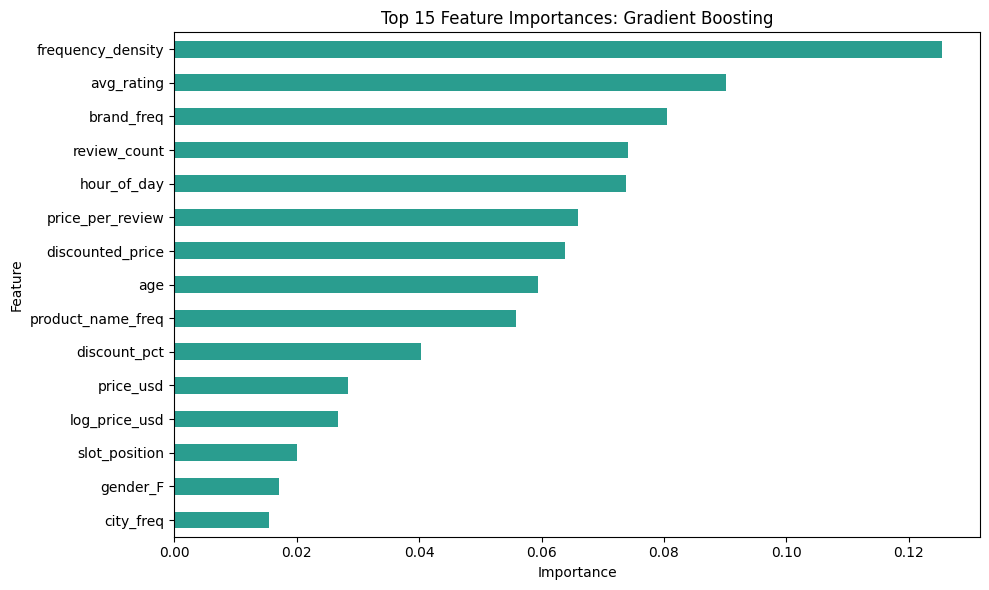

In [10]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(final_model.feature_importances_, index=X_final_train.columns)
top_15_importances = feature_importances.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
top_15_importances.plot(kind="barh", color="#2a9d8f")
plt.title(f"Top 15 Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Summary

- Reproduced the model comparison step and selected the best model using validation AUC-ROC and train-validation gap.
- Retrained the selected model on the same 1,000-row training subset.
- Reported Test AUC-ROC, the classification report at threshold 0.5, and the top 15 feature importances.